In [ ]:
# !pip install prophet
import sys
sys.path.append('../../')
import src.utils.helpers as func
import src.evaluation.metrics as meval
from src.utils.ts_diagnostics import StationarityAnalyzer, analyze_decomposition
from src.visualization import tsa_plots as tsp
from src.evaluation.interpretability import get_xbg_feature_importance
from src.evaluation.plots import plot_last_year, plot_residuals_distribution, plot_forecast
from src.features.build_features import create_basic_time_features

ImportError: cannot import name 'create_basic_features' from 'src.features.build_features' (d:\MNA\proyecto-integrador-mna\notebooks\modeling\../..\src\features\build_features.py)

In [ ]:
from statsmodels.tsa.api import ExponentialSmoothing
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf as sm_plot_acf
import numpy as np
import plotly.graph_objects as go
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd
from tabulate import tabulate
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, f_classif
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import prince as pr
import plotly.express as px
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from prophet import Prophet
import warnings
warnings.filterwarnings("ignore")

In [2]:
path = '../../data/processed/df_acumulado.parquet'
data = func.load_data(path, show_info=False)

Cargando datos desde: ../../data/processed/df_acumulado.parquet
Datos cargados exitosamente.


In [4]:
def prepare_data(data):
    df = data[['fecha', 'valor_acumulado_corregido']].copy()
    df['valor']= df['valor_acumulado_corregido'].diff()
    df.loc[0, 'valor'] = df.iloc[0]['valor_acumulado_corregido']
    df.drop(columns=['valor_acumulado_corregido'], inplace=True)
    return df


In [5]:
df = prepare_data(data)
df.head()

,fecha,valor
0,2014-01-06,131.0
1,2014-01-13,658.0
2,2014-01-20,933.0
3,2014-01-27,1023.0
4,2014-02-03,1151.0


In [6]:
df = create_basic_features(df)
features = [col for col in df.columns if col not in ['fecha', 'valor']]
df.head()

,fecha,valor,año,mes,semana,trimestre,semestre,mes_sin,mes_cos
0,2014-01-06,131.0,2014,1,2,1,1,0.500000,0.866025
1,2014-01-13,658.0,2014,1,3,1,1,0.500000,0.866025
2,2014-01-20,933.0,2014,1,4,1,1,0.500000,0.866025
3,2014-01-27,1023.0,2014,1,5,1,1,0.500000,0.866025
4,2014-02-03,1151.0,2014,2,6,1,1,0.866025,0.500000


In [ ]:
def backtesting_validation(data, model, features, tscv):
    scores = []
    for i, (train_index, test_index) in enumerate(tscv.split(data)):
        print(f"========= FOLD {i+1} =========")
        print(f"TRAIN: {len(train_index)} índices (de {train_index[0]} a {train_index[-1]})")
        print(f"TEST:  {len(test_index)} índices (de {test_index[0]} a {test_index[-1]})")
        
        train = data.iloc[train_index]
        test = data.iloc[test_index]


    return scores

In [17]:
def walk_forward_validation(data, modelo, features, tscv):
    # mae_list = []
    # rmse_list = []
    # scores = []
    for i, (train_index, test_index) in enumerate(tscv.split(data)):
        print(f"========= FOLD {i+1} =========")
        print(f"TRAIN: {len(train_index)} índices (de {train_index[0]} a {train_index[-1]})")
        print(f"TEST:  {len(test_index)} índices (de {test_index[0]} a {test_index[-1]})")
        
        # # 1. Seleccionar los datos de este fold
        # X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        # y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        # # 2. Entrenar el modelo SÓLO con datos de TRAIN
        # modelo.fit(X_train, y_train)
        
        # # 3. Predecir en el conjunto de TEST (el "futuro")
        # predicciones = modelo.predict(X_test)
        
        # # 4. Evaluar el error y guardarlo
        # error = mean_squared_error(y_test, predicciones)
        # scores.append(error)
        # print(f"Error (MSE) en Fold {i+1}: {error:.2f}\n")
print("\n--- Walk-Forward Validation ---\n")
tscv_wf = TimeSeriesSplit(n_splits=5, test_size = 52)
walk_forward_validation(df, None, None, tscv_wf)
        
def rolling_window_validation(data, model, features, tscv):
    for i, (train_index, test_index) in enumerate(tscv.split(data)):
        print(f"========= FOLD {i+1} =========")
        
        # Imprimimos los índices para ver la diferencia
        print(f"TRAIN: {len(train_index)} índices (de {train_index[0]} a {train_index[-1]})")
        print(f"TEST:  {len(test_index)} índices (de {test_index[0]} a {test_index[-1]})")

print("\n--- Rolling Window Validation ---\n")
x = len(df)
print(f"Total de registros: {x}")
weeks_per_year = 52
years = 1
window_size = weeks_per_year * years
tscv_rw = TimeSeriesSplit(n_splits=5, max_train_size=window_size, test_size=52)
rolling_window_validation(df, None, None, tscv_rw)



--- Walk-Forward Validation ---

========= FOLD 1 =========
TRAIN: 313 índices (de 0 a 312)
TEST:  52 índices (de 313 a 364)
========= FOLD 2 =========
TRAIN: 365 índices (de 0 a 364)
TEST:  52 índices (de 365 a 416)
========= FOLD 3 =========
TRAIN: 417 índices (de 0 a 416)
TEST:  52 índices (de 417 a 468)
========= FOLD 4 =========
TRAIN: 469 índices (de 0 a 468)
TEST:  52 índices (de 469 a 520)
========= FOLD 5 =========
TRAIN: 521 índices (de 0 a 520)
TEST:  52 índices (de 521 a 572)

--- Rolling Window Validation ---

Total de registros: 573
========= FOLD 1 =========
TRAIN: 156 índices (de 157 a 312)
TEST:  52 índices (de 313 a 364)
========= FOLD 2 =========
TRAIN: 156 índices (de 209 a 364)
TEST:  52 índices (de 365 a 416)
========= FOLD 3 =========
TRAIN: 156 índices (de 261 a 416)
TEST:  52 índices (de 417 a 468)
========= FOLD 4 =========
TRAIN: 156 índices (de 313 a 468)
TEST:  52 índices (de 469 a 520)
========= FOLD 5 =========
TRAIN: 156 índices (de 365 a 520)
TEST:  52

In [6]:
# Prophet expects lowercase column names 'ds' and 'y'
data_prophet = df[['fecha', 'valor']].copy().rename(columns={'fecha': 'ds', 'valor': 'y'})
# ensure ds is datetime
data_prophet['ds'] = pd.to_datetime(data_prophet['ds'])

model = Prophet()
model.fit(data_prophet)

22:39:36 - cmdstanpy - INFO - Chain [1] start processing
22:39:36 - cmdstanpy - INFO - Chain [1] done processing


00:53:12 - cmdstanpy - INFO - Chain [1] start processing
00:53:12 - cmdstanpy - INFO - Chain [1] done processing


Iniciando backtesting (Walk-Forward)...


  0%|          | 0/4 [00:00<?, ?it/s]

00:53:12 - cmdstanpy - INFO - Chain [1] start processing
00:53:12 - cmdstanpy - INFO - Chain [1] done processing
00:53:13 - cmdstanpy - INFO - Chain [1] start processing
00:53:13 - cmdstanpy - INFO - Chain [1] done processing
00:53:13 - cmdstanpy - INFO - Chain [1] start processing
00:53:13 - cmdstanpy - INFO - Chain [1] done processing
00:53:13 - cmdstanpy - INFO - Chain [1] start processing
00:53:13 - cmdstanpy - INFO - Chain [1] done processing
d:\conda_env\depression-analysis\Lib\site-packages\prophet\plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
d:\conda_env\depression-analysis\Lib\site-packages\prophet\plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype(

Backtesting completado.

--- Métricas de Rendimiento Promedio (Horizonte = 1 año) ---
     horizon        mse      rmse       mae      mape     mdape     smape  \
185 358 days  25.591888  5.058843  4.355853  0.031375  0.031381  0.030763   
186 359 days  24.577445  4.957564  4.141648  0.029887  0.027610  0.029299   
187 360 days  22.653816  4.759602  3.877461  0.027927  0.022560  0.027390   
188 361 days  19.335392  4.397203  3.633038  0.025843  0.022560  0.025455   
189 365 days  18.201303  4.266299  3.503996  0.024910  0.021356  0.024568   

     coverage  
185       1.0  
186       1.0  
187       1.0  
188       1.0  
189       1.0  


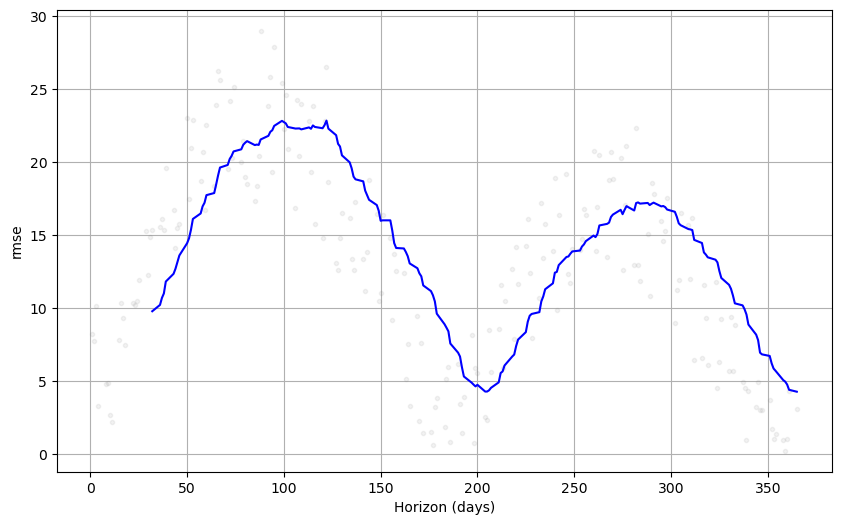

In [3]:
import pandas as pd
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
import numpy as np
# 1. PREPARAR DATOS (Simulamos tus 10 años de datos semanales)
# 10 años * 52.14 semanas/año ≈ 521 semanas
# (Usaré 522 semanas = 10 años + 1 semana para el ejemplo)
fechas_semanales = pd.date_range(start='2014-01-05', periods=522, freq='W')
casos_semanales = (np.sin(np.arange(522) * np.pi / (52/2)) * 20 + # Estacionalidad anual
                   np.arange(522) * 0.1 +                     # Tendencia ligera
                   100 + np.random.rand(522) * 10)           # Ruido

df = pd.DataFrame({'ds': fechas_semanales, 'y': casos_semanales})
df['ds'] = pd.to_datetime(df['ds'])

# 2. CONFIGURAR Y ENTRENAR EL MODELO
m = Prophet(
    weekly_seasonality=False, # Ya tenemos datos semanales, no hay "día de la semana"
    yearly_seasonality=False, # La quitamos para añadirla manualmente
)

# ¡IMPORTANTE! Tus datos son semanales, la estacionalidad es anual.
# El "periodo" no es en días, sino en semanas (52.14 ≈ 365.25 / 7)
# Prophet recomienda usar el valor en días.
# Para estacionalidad anual en datos semanales, se recomienda usar:
m.add_seasonality(name='anual', period=365.25 / 7, fourier_order=10)

m.fit(df) # Entrenamos con TODOS los datos (Prophet lo necesita como referencia)


# 3. EJECUTAR EL BACKTESTING (WALK-FORWARD)

print("Iniciando backtesting (Walk-Forward)...")
# Usamos "días" para que Prophet entienda las ventanas de tiempo
df_cv = cross_validation(m, 
                         initial='1826 days',  # 5 años de entrenamiento inicial
                         period='365 days',    # Re-entrenar cada 1 año
                         horizon='365 days')   # Predecir 1 año a futuro

print("Backtesting completado.")

# 4. OBTENER MÉTRICAS DE RENDIMIENTO PROMEDIO
df_p = performance_metrics(df_cv)

print("\n--- Métricas de Rendimiento Promedio (Horizonte = 1 año) ---")
# Mostramos las métricas promedio para todo el horizonte de 365 días
print(df_p.tail(5))


# 5. VISUALIZAR EL ERROR
# Esto te muestra cómo aumenta el error a medida que predices más a futuro
fig = plot_cross_validation_metric(df_cv, metric='rmse')
# (Esta figura es clave para ver si tu error se "dispara" a las 52 semanas)